We are going to run the same model but this time we are going to use the package xarray to handle all the backend we just did manually

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Data Loading

we will read some data froma  spreadsheet as before

In [4]:
vehicles = pd.read_csv(r"data\vehicles.csv")
vehicles

,vehicle,power_kwh,fuel
0,tractor,9000,diesel
1,lawnmower,450,petrol
2,generator,1100,petrol
3,generator,2300,diesel


we can use xarray to turn it directly into a 2D dataset

 _(hint click the 3 stacked disks data tab to see the numpy array within)_

In [11]:
power_kwh = (vehicles
            .set_index(["vehicle", "fuel"])
            .to_xarray())  # power_kwh becomes a data variable
power_kwh

<xarray.Dataset> Size: 88B
Dimensions:    (vehicle: 3, fuel: 2)
Coordinates:
  * vehicle    (vehicle) object 24B 'generator' 'lawnmower' 'tractor'
  * fuel       (fuel) object 16B 'diesel' 'petrol'
Data variables:
    power_kwh  (vehicle, fuel) float64 48B 2.3e+03 1.1e+03 nan 450.0 9e+03 nan

ok lets import fuel. this is still 1D data so we don't need to do anything different here, but lets put it into numpy for later

In [14]:
fuel = pd.read_csv(r"data\fuel.csv")
fuel

,fuel,emissions_tons_per_kwh
0,petrol,0.25
1,diesel,0.35


not that this will make a `DataArray`, whereas the power_kwh import makes a `Dataset`. This refers to the number of dimensions that are present

In [ ]:
emissions_tons_per_kwh = (fuel
                .set_index("fuel")["emissions_tons_per_kwh"]
                .to_xarray())
emissions_tons_per_kwh

<xarray.DataArray 'emissions_tons_per_kwh' (fuel: 2)> Size: 16B
array([0.25, 0.35])
Coordinates:
  * fuel     (fuel) object 16B 'petrol' 'diesel'

setting up the model window is still the same

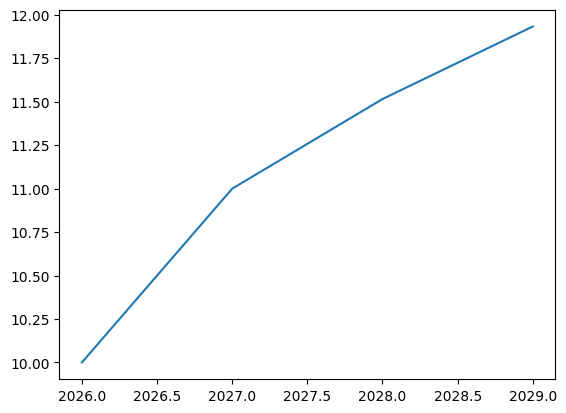

In [22]:
def calc_carbon_cost(year):
    cost = 10 + ((year-2026)**0.6)
    return cost

years = np.arange(2026,2030,1)
years

offset_base_cost_gbp_per_ton = calc_carbon_cost(years)

plt.plot(years, offset_base_cost_gbp_per_ton)

lets make this into an xarray too

In [ ]:
offset_base_cost_gbp_per_ton = xr.DataArray(
    offset_base_cost_gbp_per_ton,
    coords={"year": years},
    dims=("year",),
    name="offset_base_cost_gbp_per_ton",
)
offset_base_cost_gbp_per_ton

<xarray.DataArray 'offset_base_cost_gbp_per_ton' (year: 4)> Size: 32B
array([10.        , 11.        , 11.51571657, 11.93318204])
Coordinates:
  * year     (year) int64 32B 2026 2027 2028 2029

now we have some data, lets merge it all togehter. In this methodology we can go back to having one main dataframe, but this time with multiple dimensions. See the dimension column will say (vehicle) or (vehicle, fuel) etc to indicate which dimensions the values have

In [ ]:
ds = power_kwh.merge(offset_base_cost_gbp_per_ton)

ds['emissions_tons_per_kwh'] = emissions_tons_per_kwh

ds

<xarray.Dataset> Size: 168B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93

now we do the calculations

In [26]:
ds['emissions_tons_per_year'] = ds['emissions_tons_per_kwh'] * ds['power_kwh']
ds

<xarray.Dataset> Size: 216B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_year       (fuel, vehicle) float64 48B 805.0 nan ... nan

the handling of the creation of the 3d matrix is all managed by xarray so you don't need to worry about the adding new dimensions

In [ ]:
ds['offset_cost_gbp_per_year'] = ds['offset_base_cost_gbp_per_ton'] * ds['emissions_tons_per_year']
ds

<xarray.Dataset> Size: 408B
Dimensions:                       (vehicle: 3, fuel: 2, year: 4)
Coordinates:
  * vehicle                       (vehicle) object 24B 'generator' ... 'tractor'
  * fuel                          (fuel) object 16B 'diesel' 'petrol'
  * year                          (year) int64 32B 2026 2027 2028 2029
Data variables:
    power_kwh                     (vehicle, fuel) float64 48B 2.3e+03 ... nan
    emissions_tons_per_kwh        (fuel) float64 16B 0.35 0.25
    offset_base_cost_gbp_per_ton  (year) float64 32B 10.0 11.0 11.52 11.93
    emissions_tons_per_year       (fuel, vehicle) float64 48B 805.0 nan ... nan
    offset_cost_gbp_per_year      (year, fuel, vehicle) float64 192B 8.05e+03...

to get say the 2D slice of values from the year 2027 we do

In [34]:
ds.sel(dict(year=2027))['offset_cost_gbp_per_year']

<xarray.DataArray 'offset_cost_gbp_per_year' (fuel: 2, vehicle: 3)> Size: 48B
array([[ 8855. ,     nan, 34650. ],
       [ 3025. ,  1237.5,     nan]])
Coordinates:
  * fuel     (fuel) object 16B 'diesel' 'petrol'
  * vehicle  (vehicle) object 24B 'generator' 'lawnmower' 'tractor'
    year     int64 8B 2027

say we want to extract from this the cost over time split per vehicle type. This is summing together the two types of generator

In [38]:
offset_cost_gbp_per_year_by_vehicle = ds.sum(dim='fuel')['offset_cost_gbp_per_year']
offset_cost_gbp_per_year_by_vehicle

<xarray.DataArray 'offset_cost_gbp_per_year' (year: 4, vehicle: 3)> Size: 96B
array([[10800.        ,  1125.        , 31500.        ],
       [11880.        ,  1237.5       , 34650.        ],
       [12436.97389183,  1295.51811373, 36274.50718451],
       [12887.83660853,  1342.48298005, 37589.52344154]])
Coordinates:
  * year     (year) int64 32B 2026 2027 2028 2029
  * vehicle  (vehicle) object 24B 'generator' 'lawnmower' 'tractor'

and then plot

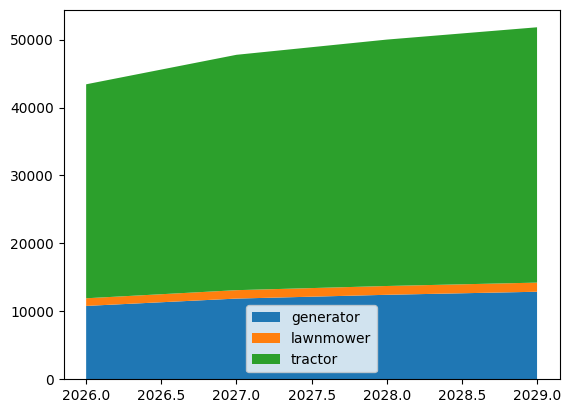

In [44]:
plt.stackplot(offset_cost_gbp_per_year_by_vehicle['year'],
              offset_cost_gbp_per_year_by_vehicle.values.T,
              labels=offset_cost_gbp_per_year_by_vehicle['vehicle'].values
              )
plt.legend()

why do we do all of this!? lets look at the total number of values stored. This dataframe has $3 + 2 + 4 = 9$ dimension labels and $4 + 2 + 4 + 4 + 16 = 30$ values for a total of 39

In [63]:
print(ds.dims)
ds.count()

FrozenMappingWarningOnValuesAccess({'vehicle': 3, 'fuel': 2, 'year': 4})


<xarray.Dataset> Size: 40B
Dimensions:                       ()
Data variables:
    power_kwh                     int64 8B 4
    emissions_tons_per_kwh        int64 8B 2
    offset_base_cost_gbp_per_ton  int64 8B 4
    emissions_tons_per_year       int64 8B 4
    offset_cost_gbp_per_year      int64 8B 16

compare this to the pandas in the first notebook, which had $3 \times 2 \times 4 = 16$ rows. thats $16 \times 3 = 48$ labels and $16 \times 5 = 80$ values for a total of 128. This is a very simple modele and this pythonic approach is already 3 times more disk efficient than the spreadsheet approach

if we were to compute the total number of operations performed in both workflows we would find the more pythonic workflow similarily compute efficient.